<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/Standard_banner.png' align='right' width='100%'/>

<a href="../Index.ipynb" target="_blank"><< Index</a>
<br>
<a href="./2_4_OLCI_matchup_validation.ipynb" target="_blank"><< OLCI validation with the ThoMaS match-up toolkit</a>

<font color="#138D75">**Copernicus Marine Training Service**</font> <br>
**Copyright:** 2024 European Union <br>
**License:** MIT <br>
**Authors:** Ben Loveday (EUMETSAT/Innoflair UG), Hayley Evers-King (EUMETSAT), Juan Ignacio-Gossn (EUMETSAT)

<html>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-olci"><img src="https://img.shields.io/badge/open-EUMETLAB-E67E22.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://user.eumetsat.int/data/themes/marine"><img src="https://img.shields.io/badge/open-USER PORTAL-154360.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.eumetsat.int%2Feumetlab%2Foceans%2Focean-training%2Fsensors%2Flearn-olci/HEAD?labpath=2_OLCI_advanced%2F2_5_multisensor_matchup_validation.ipynb"><img src="https://mybinder.org/badge_logo.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://jupyterhub.prod.wekeo2.eu/hub/user-redirect/lab/tree/public/wekeo4oceans/learn-olci/2_OLCI_advanced/2_5_multisensor_matchup_validation.ipynb"><img src="https://img.shields.io/badge/launch-WEKEO-1a4696.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://code.insula.destine.eu/hub/"><img src="https://img.shields.io/badge/launch-DestinE-f43fd3.svg"></a></div></div>
</html>

<div class="alert alert-block alert-success">
<h3>Learn OLCI: Advanced</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>
    
This notebook has the following prerequisites:
- **<a href="https://eoportal.eumetsat.int/" target="_blank">A EUMETSAT Earth Observation Portal account</a>** to enable you to download products from the EUMETSAT Data Store.

There are no prerequisite notebooks for this module.
</div>
<hr>

# 2.4 Multi-sensor validation with the ThoMaS match-up toolkit

### Data used

| Dataset | EUMETSAT collection ID| EUMETSAT collection<br>description | WEkEO dataset ID | WEkEO description | Earthdata ID | Earthdata description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|:-------:|:-------:|
| Sentinel-3 OLCI level 2 full resolution (operational) | EO:EUM:DAT:0407 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_2_WFR___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:OL_2_WFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_2_WFR___" target="_blank">Description</a> |
| Sentinel-3 OLCI level 2 full resolution (version BC003) reprocessing | EO:EUM:DAT:0556 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0556" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:0556 | <a href="https://wekeo.copernicus.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3A0556" target="_blank">Description</a> |
| Sentinel-3 OLCI level 1b full resolution (operational) | EO:EUM:DAT:0409 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_1_EFR___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:OL_1_EFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_1_EFR___" target="_blank">Description</a> |
| Sentinel-3 OLCI level 1b full resolution (version BC004) reprocessing*| EO:EUM:DAT:0885 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:0885" target="_blank">Description</a> | EO:EUM:DAT:0885 | <a href="https://wekeo.copernicus.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3A0885" target="_blank">Description</a> |
| Aqua MODIS Regional Ocean Color (OC) Data, version R2022.0 | - | - | - | - | MODISA_L2_OC | <a href="https://search.earthdata.nasa.gov/search/granules/collection-details?p=C2330511440-OB_DAAC&pg[0][v]=f&pg[0][gsk]=-start_date&fi=MODIS&fl=2%2B-%2BGeophys.%2BVariables%252C%2BSensor%2BCoordinates&fsm0=Ocean+Optics&fst0=Oceans" target="_blank">Description</a> |
| PACE OCI Level-2 Regional Apparent Optical Properties - Near Real-time (NRT) Data, version 3.0 | - | - | - | - | PACE_OCI_L2_AOP_NRT | <a href="https://search.earthdata.nasa.gov/search?q=PACE_OCI_L2_AOP_NRT">Description</a> |
| Suomi-NPP VIIRS Level-2 Regional Ocean Color (OC) - Near Real-time (NRT) Data, version 2022.0 | - | - | - | - | VIIRSN_L2_OC | <a href="https://search.earthdata.nasa.gov/search?q=VIIRSN_L2_OC">Description</a> |

### Learning outcomes

At the end of this notebook you will know;
* how to use the ThoMaS toolkit to perform multisensor match-up validation extractions and analyses

### Outline

Validation studies are essential to ensuring satellite sensor performance and a necessary part of algorithm development. For ocean colour studies, match-up analyses are a key part of validation. The ThoMaS (Tool to generate Matchups of OC products with Sentinel-3/OLCI) package provides a comprehensive set of tools to help with the validation of ocean colour products for various sensors, including Sentinel-3 OLCI, MODIS Aqua and PACE OCI, supporting many common workfows including;
* satellite data acquisition
* mini file extraction
* *in situ* data management
* BRDF correction

ThoMaS is written in Python and is made available through a **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS" target="_blank">EUMETSAT Gitlab repository</a>**. The package can be used from the command line, via GUI, or imported as a Python library, as done here. This notebook contains 3 examples of how to use ThoMaS in various ways, but the capability shown is not exhaustive. Many more command-line examples are included in the repository, and we encourage users to familiarise themselves with both the **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README.md" target="_blank">project README</a>** and **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md" target="_blank"> example README</a>** for more information.

The examples given here should give you some insight into what ThoMaS can do, but we encourage you to build on these to facilitate your own validation workflows.

<div class="alert alert-info" role="alert">

## <a id='TOC-TOP'></a>Contents

</div>

0. [Defining functions](#section0)
1. [Getting the ThoMaS toolkit](#section1)
1. [Configuring ThoMaS](#section2)
1. [Example 1: Satellite product downloads only](#section3)
1. [Example 2: Full match-up exercise using MOBY SeaBASS data](#section4)
1. [Example 3: Full match-up exercise with in situ data from an AERONET-OC site](#section5)
2. [What next?](#section6)

<hr>

We begin by importing all of the libraries that we need to run this notebook. If you have built your python environment (`cmts_learn_olci`) using the file provided in this repository, then you should have everything you need. For more information on building environment, please see the repository **<a href="../README.md" target="_blank">README</a>**.

In [1]:
import os                                   # a library that allows us access to basic operating system commands like making directories
import sys                                  # a library that provides access to system commands
import pandas as pd                         # a library that helps us manipulate data 
import shutil                               # a library that allows us access to basic operating system commands like copy
import numpy as np                          # a library that provides support for array-based mathematics
from IPython.display import Image, display  # a library that helps us plot images
import glob                                 # a library that helps us find files

<div class="alert alert-warning" role="alert">

## <a id='section0'></a>Defining functions
[Back to top](#TOC-TOP)

</div>

Before we go any further we are going to define a quick function that helps us to write our configuration options to a file.

*Note: We don't need to write our configurations in python, we could always just write the configuration file directly and point ThoMaS to it.*

In [2]:
# Write config_params sections into config_file.ini
def write_config_file(path_to_config_file,config_params):
    with open(path_to_config_file, 'w') as text_file:
        for section,section_params in config_params.items():
            text_file.write('\n[%s]\n' % (section))
            for param, value in section_params.items():
                text_file.write('%s: %s\n' % (param, value))

<div class="alert alert-info" role="alert">

## <a id='section1'></a>Getting the ThoMaS toolkit
[Back to top](#TOC-TOP)

</div>

The first thing we need to do is retrieve the tool kit itself. We can do this using the external `! git clone` command. This will create a directory called **ThoMaS** in this path and make the code available for import.

In [3]:
if os.path.exists(os.path.join("ThoMaS", "main.py")):
    print("ThoMaS is already installed.")
else:
    ! git clone https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS.git

ThoMaS is already installed.


<div class="alert alert-info" role="alert">

## <a id='section2'></a>Configuring and loading ThoMaS
[Back to top](#TOC-TOP)

</div>

Before you use ThoMas, you must ensure that you have have completed the following two steps:
1. Ensure that you have all the Python dependencies you need to run ThoMaS. If you have installed and activated the **cmts_learn_olci** environment then you are all set.
1. Ensure that ThoMaS can access the EUMETSAT Data Store, which you can do by completing the "**EUMDAC**" section of the <a href="../working-with-python/API_authentication.ipynb" target="_blank"> set credentials notebook</a>.

ThoMaS can be used from the <a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md" target="_blank">command line</a>, but here we will use it as a Python library. Lets import ThoMaS into our notebook.

In [4]:
sys.path.append("ThoMaS")
from main import ThoMaS_main as ThoMaS

Now we should have ThoMaS imported and configured for use, so we can proceed with our examples.

<div class="alert alert-info" role="alert">

## <a id='section3'></a>Example 1: Satellite product downloads only (<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md?ref_type=heads" target="_blank">ThoMaS example 1</a>)
[Back to top](#TOC-TOP)

</div>

<div class="alert alert-success" role="alert">

Run ThoMaS for:

1. Single location
1. Single time window
1. Only download satellite data

</div>

#### Description
<hr>
In this case we are going to look at extracting data over a single time window over a static region. We are going to acquire OLCI data from Sentinel-3a and Sentinel-3b from the EUMETSAT Data Store and MODIS Aqua data from the NASA Earthdata portal. We are **not** going to compare the results with *in situ* data. Below are our requirements for this workflow:

1. I want to download Sen-3/OLCI and Aqua/MODIS data from the outer Gironde estuary at location (45.6N, 1.6W), where I deployed an in situ instrument measuring continuously during the first 5 days of September 2021.
1. I want data from both S3A and S3B, and both L1 and L2 of the current operational collection. Only full resolution (FR).
1. I want Aqua data for L2 
1. I just want to obtain the S3 files (SatData), I am not interested in obtaining minifiles and I have my own scripts to compute the statistics of the extractions and the comparison with insitu.
1. I already cloned successfully the ThoMaS code into this directory
1. I have already loaded the correct Python environment (either cmts_learn_olci or thomas).
1. My EUMETSAT Data Store credentials are already stored at ~/.eumdac_credentials.json
1. My EarthData credentials are already stored at ~/.obpg_credentials.json
1. I want everything related to the run to be stored in the "Gironde" folder in this directory

<hr>

Lets start by defining an output path for our analysis. Everything we do will be stored in this directory.

In [5]:
output_path = os.path.join(os.getcwd(), "Gironde")
if not os.path.exists(output_path):
    os.mkdir(output_path)

Now we are going to define a configuration file that sets the parameters for our analysis. We will create this as a dictionary.

In [6]:
# Build your config_file.ini
path_to_config_file = os.path.join(output_path, 'config_file.ini')
config_params = {}

The first section of our configuration are our global settings. A key to this is the definition of our "global workflow". This defines the processing steps that we want to perform on our data. In this case, we specify that we want to download satellite data (SatData), only. Each of these steps requires another configuration file section, which we will come to later.

In [7]:
# global
config_params['global'] = {}
config_params['global']['path_output'] = output_path
config_params['global']['SetID'] = 'Gironde'

# workflow
config_params['workflow'] = {}
config_params['workflow']['workflow'] = 'SatData'

Now we will define the parameters for each of our workflow sections, stating with our satellite data. Here we will entire all the relevant parameters that will determine the data we will use.

In [8]:
# satellite
config_params['satellite'] = {}
config_params['satellite']['satellite_path-to-SatData'] = os.path.join(output_path, 'SatData')
config_params['satellite']['satellite_source'] = 'online'
config_params['satellite']['satellite_collections'] = 'operational'
config_params['satellite']['satellite_levels'] = 'L1, L2'
config_params['satellite']['satellite_platforms'] = 'Aqua, PACE, NOAA-20'
config_params['satellite']['satellite_resolutions'] = 'FR'

In [9]:
write_config_file(path_to_config_file, config_params)

The last thing we need to do is define the specifics of our extraction site; e.g. location and time window. We do this in a second file, as below.

In [10]:
# Define the path
path_to_latLonTimeRanges = os.path.join(output_path, 'latLonTimeRanges.csv')

# Define the necessary inputs
latLonTime = pd.DataFrame(columns = ['Lat', 'Lon', 'time_start', 'time_stop'])
latLonTime.loc[0, 'Lat'] = 45.6
latLonTime.loc[0, 'Lon'] = -16
latLonTime.loc[0, 'time_start'] = '2021-09-01T00:00:00'
latLonTime.loc[0, 'time_stop'] = '2021-09-05T23:59:59'

# Store as csv file
latLonTime.to_csv(path_to_latLonTimeRanges, index=False)

Now everything is defined we can run ThoMaS. The only thing we need to do is pass the tool kit the path to our configuration file.

In [11]:
# Run ThoMaS and check all the outputs in the output directory
ThoMaS(path_to_config_file)


Running Gironde

Building satellite_datasets file from specified options in config_file...

Step SatData


Enter your Earthdata Login username:  bloveday
Enter your Earthdata password:  ········


Search NASA Earthaccess, sensor_level=MODISA_L2_OC, lat=-16, lon=45.6, time_start=2021-09-01T00:00:00, time_stop=2021-09-05T23:59:59
NASA Earthaccess, downloading ... 


QUEUEING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/6 [00:00<?, ?it/s]

...

Writing SatDataList for set Aqua_MODIS_L2_l2gen_OBPG_FR_Gironde to: /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/sensors/learn-olci/2_OLCI_advanced/Gironde/SatDataLists/SatDataList_Aqua_MODIS_L2_l2gen_OBPG_FR_Gironde.txt
Search NASA Earthaccess, sensor_level=PACE_OCI_L2_AOP_NRT, lat=-16, lon=45.6, time_start=2021-09-01T00:00:00, time_stop=2021-09-05T23:59:59
Writing SatDataList for set PACE_OCI_L2_l2gen_OBPG_FR_Gironde to: /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/sensors/learn-olci/2_OLCI_advanced/Gironde/SatDataLists/SatDataList_PACE_OCI_L2_l2gen_OBPG_FR_Gironde.txt
Search NASA Earthaccess, sensor_level=VIIRSJ1_L2_OC, lat=-16, lon=45.6, time_start=2021-09-01T00:00:00, time_stop=2021-09-05T23:59:59
NASA Earthaccess, downloading ... 


QUEUEING TASKS | :   0%|          | 0/8 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/8 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/8 [00:00<?, ?it/s]

Writing SatDataList for set NOAA-20_VIIRS_L2_l2gen_OBPG_FR_Gironde to: /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/sensors/learn-olci/2_OLCI_advanced/Gironde/SatDataLists/SatDataList_NOAA-20_VIIRS_L2_l2gen_OBPG_FR_Gironde.txt

Run "Gironde" finished


ThoMaS finished!


If all went well, in our experiment directory you should now have several folders that contain the outputs from the ThoMaS analysis.
* SatData contains the full downloaded products
* SatDataLists contains information on the inventory of downloaded data

<div class="alert alert-info" role="alert">

## <a id='section4'></a>Example 2: Full match-up exercise using MOBY SeaBASS data (<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md?ref_type=heads" target="_blank">ThoMaS example 6</a>)
[Back to top](#TOC-TOP)

</div>

<div class="alert alert-success" role="alert">

Run ThoMaS for:

1. full matchup exercise: satellite extractions + minifiles + extraction statistics + matchup statistics
1. insitu data already available in SeaBASS/OCDB format
1. apply the <a href="https://ioccg.org/bibliography/morel-a-antoine-d-and-b-gentili-2002/" target="_blank">Morel, Antoine and Gentili, 2002</a> BRDF correction
1. EUMETSAT standard protocol for extractions and for insitu-extraction comparison.

</div>

#### Description
<hr>

In this case we are going to look at a full match-up analysis using a hyperspectral *in situ* measurements from Moby, in SEABASS format, and stored in a local database. The measurements are not corrected for BRDF effects. 

1. I have prepared a set of hyperspectral Rrs insitu measurements from <a href="https://mlml.sjsu.edu/moby/" target="_blank">MOBY</a> in SeaBASS format not corrected for BRDF effects.
1. I wish to get matchups between this MOBY subset and S3A/OLCI standard FR Level 2 SatData:
    * using the standard extraction protocol from EUMETSAT,
    * an extraction window of 3x3,
    * an insitu-satellite time difference threshold of 1 hour (3600 seconds).
    * to propagate - if existent - "uncertainties" in insitu and/or satellite data to the performance metrics by running Monte-Carlo simulations. NB: For the moment, the "uncertainty" in the satellite data is usually taken as the standard deviation of the set of valid macropixels.
1. I am not interested in getting ancillary data from ECMWF corresponding to the insitu data.
1. I want to apply the Morel, Antoine and Gentili 2002 BRDF correction to both satellite and insitu.
1. I may have several insitu measurements corresponding to one single SatData within the time window that I selected, but I wish to keep only the closest in time with the satellite overpass.
1. I wish my satellite data to be stored in the ./MOBY/SatData directory. All the other outputs (IDB, minifiles, EDB, MDB, etc.) to be stored in the ./MOBY directory

<hr>

We are going to perform exactly the same steps as we did in example 1, beginning with defining our output path.

In [12]:
# Define and create the path to your main output directory for this exercise.
output_path = os.path.join(os.getcwd(), "MOBY")
if not os.path.exists(output_path):
    os.mkdir(output_path)

Lets now copy some SEABASS/OCDB format *in situ* data into this experiment path (this is included in command line example 6).

In [13]:
# Copy the MOBY sample data (/ThoMaS/examples/examples6/MOBY_OCDB.csv) to your target output directory
path_insitu = os.path.join(output_path, 'MOBY_OCDB.sb')
shutil.copy(os.path.join(os.getcwd(), "ThoMaS", "examples", "06_full_matchup_workflow_MOBY_SeaBASS", "MOBY", "MOBY_OCDB.sb"), path_insitu);

Lets take a quick look at a subset of the data....

In [14]:
with open(path_insitu) as file:
    print('\t'.join(["Station", "\t\tDate", "\tTime", "\tStatus"]))
    for line in file:
        if not any(ext in line[0] for ext in ['/', '!']):
            print('\t'.join(line.rstrip().split(',')[0:4]))

Station			Date		Time		Status
M260_2016061020d	20160610	21:14:37	Good
M260_2016071120d	20160711	21:14:32	Good
M260_2016071920d	20160719	21:15:05	Questionable
M260_2016072220d	20160722	21:14:37	Questionable
M260_2016080320d	20160803	21:14:32	Good
M261_2016082620d	20160826	21:13:24	Good
M261_2016093020d	20160930	21:13:54	Good
M261_2016100820d	20161008	21:13:27	Good
M261_2016101920d	20161019	21:15:10	Good
M261_2017010420d	20170104	21:06:21	Good
M261_2017010520d	20170105	21:06:28	Good
M261_2017011120d	20170111	21:05:57	Good
M261_2017011220d	20170112	21:06:00	Good
M262_2017022320d	20170223	21:15:58	Questionable
M262_2017031520d	20170315	21:15:54	Questionable
M262_2017032620d	20170326	21:15:56	Good
M262_2017040320d	20170403	21:14:46	Good
M262_2017052320d	20170523	21:17:10	Good
M262_2017052720d	20170527	21:16:57	Good
M262_2017060420d	20170604	21:17:47	Good
M262_2017061920d	20170619	21:16:51	Questionable
M263_2017080420d	20170804	21:14:21	Good
M263_2017082020d	20170820	21:12:26	Questionable
M26

As before we will define a configuration file. However, there are some differences to before. We need to define all the steps in our analysis, including:
* how we handle the *in situ* data
* how we handle the satellite data
* how we handle the generation of satellite minifiles
* how we handle the construction of the extraction data base
* how we handle the generation of the match-up database (MDB)

Lets set up our configuration file to specify all the relevant steps in our desired workflow.

In [15]:
# Build your config_file.ini
path_to_config_file = os.path.join(output_path, 'config_file.ini')
config_params = {}

# global
config_params['global'] = {}
config_params['global']['path_output'] = output_path
config_params['global']['SetID'] = 'MOBY'

# workflow
config_params['workflow'] = {}
config_params['workflow']['workflow'] = 'insitu, SatData, minifiles, EDB, MDB'

# insitu
config_params['insitu'] = {}
config_params['insitu']['insitu_input'] = path_insitu
config_params['insitu']['insitu_satelliteTimeToleranceSeconds'] = 3600
config_params['insitu']['insitu_getAncillary'] = False 
config_params['insitu']['insitu_BRDF'] = 'M02'

# satellite
config_params['satellite'] = {}
config_params['satellite']['satellite_path-to-SatData'] = os.path.join(output_path, 'SatData')
config_params['satellite']['satellite_source'] = 'online'
config_params['satellite']['satellite_platforms'] = 'S3A'
config_params['satellite']['satellite_resolutions'] = 'FR'
config_params['satellite']['satellite_BRDF'] = 'M02'

# minifiles
config_params['minifiles'] = {}
config_params['minifiles']['minifiles_winSize'] = 5

# EDB
config_params['EDB'] = {}
config_params['EDB']['EDB_protocols_L2'] = 'EUMETSAT_standard_L2'
config_params['EDB']['EDB_winSizes'] = 5

# MDB
config_params['MDB'] = {}
config_params['MDB']['MDB_time-interpolation'] = 'insitu2satellite_NN'
config_params['MDB']['MDB_stats_plots'] = True
config_params['MDB']['MDB_stats_MonteCarlo'] = 100
config_params['MDB']['MDB_stats_protocol'] = 'EUMETSAT_standard_L2'

# Write config_params sections into config_file.ini
write_config_file(path_to_config_file, config_params)

Lets run this configuration (which will take some time)...

In [16]:
# Run ThoMaS and check all the outputs in the output directory
ThoMaS(path_to_config_file)


Running MOBY

Building satellite_datasets file from specified options in config_file...

Step insitu
Creating IDB (in situ database) netcdf file and calculating timeRanges and satellite datasets from input SeaBASS/OCDB file (in situ)
File not altered by sanitiser, skipping
Header "water_depth" could not be converted to body field, check header value.

Step SatData
Search EUMETSAT Data Store: Sentinel-3A (lat=20.81716666666667, lon=-157.19016666666667) between 2016-06-10T20:14:37 (UTC) and 2016-06-10T22:14:37 (UTC)...
Search EUMETSAT Data Store: Sentinel-3A (lat=20.81716666666667, lon=-157.19016666666667) between 2016-06-10T20:14:37 (UTC) and 2016-06-10T22:14:37 (UTC)...
Search EUMETSAT Data Store: Sentinel-3A (lat=20.81716666666667, lon=-157.19016666666667) between 2016-07-11T20:14:32 (UTC) and 2016-07-11T22:14:32 (UTC)...
Search EUMETSAT Data Store: Sentinel-3A (lat=20.81716666666667, lon=-157.19016666666667) between 2016-07-11T20:14:32 (UTC) and 2016-07-11T22:14:32 (UTC)...
Search E

...and check our outputs. In this case, we have run a full analysis, so along side all of our data we have some summary plots. Lets view some...

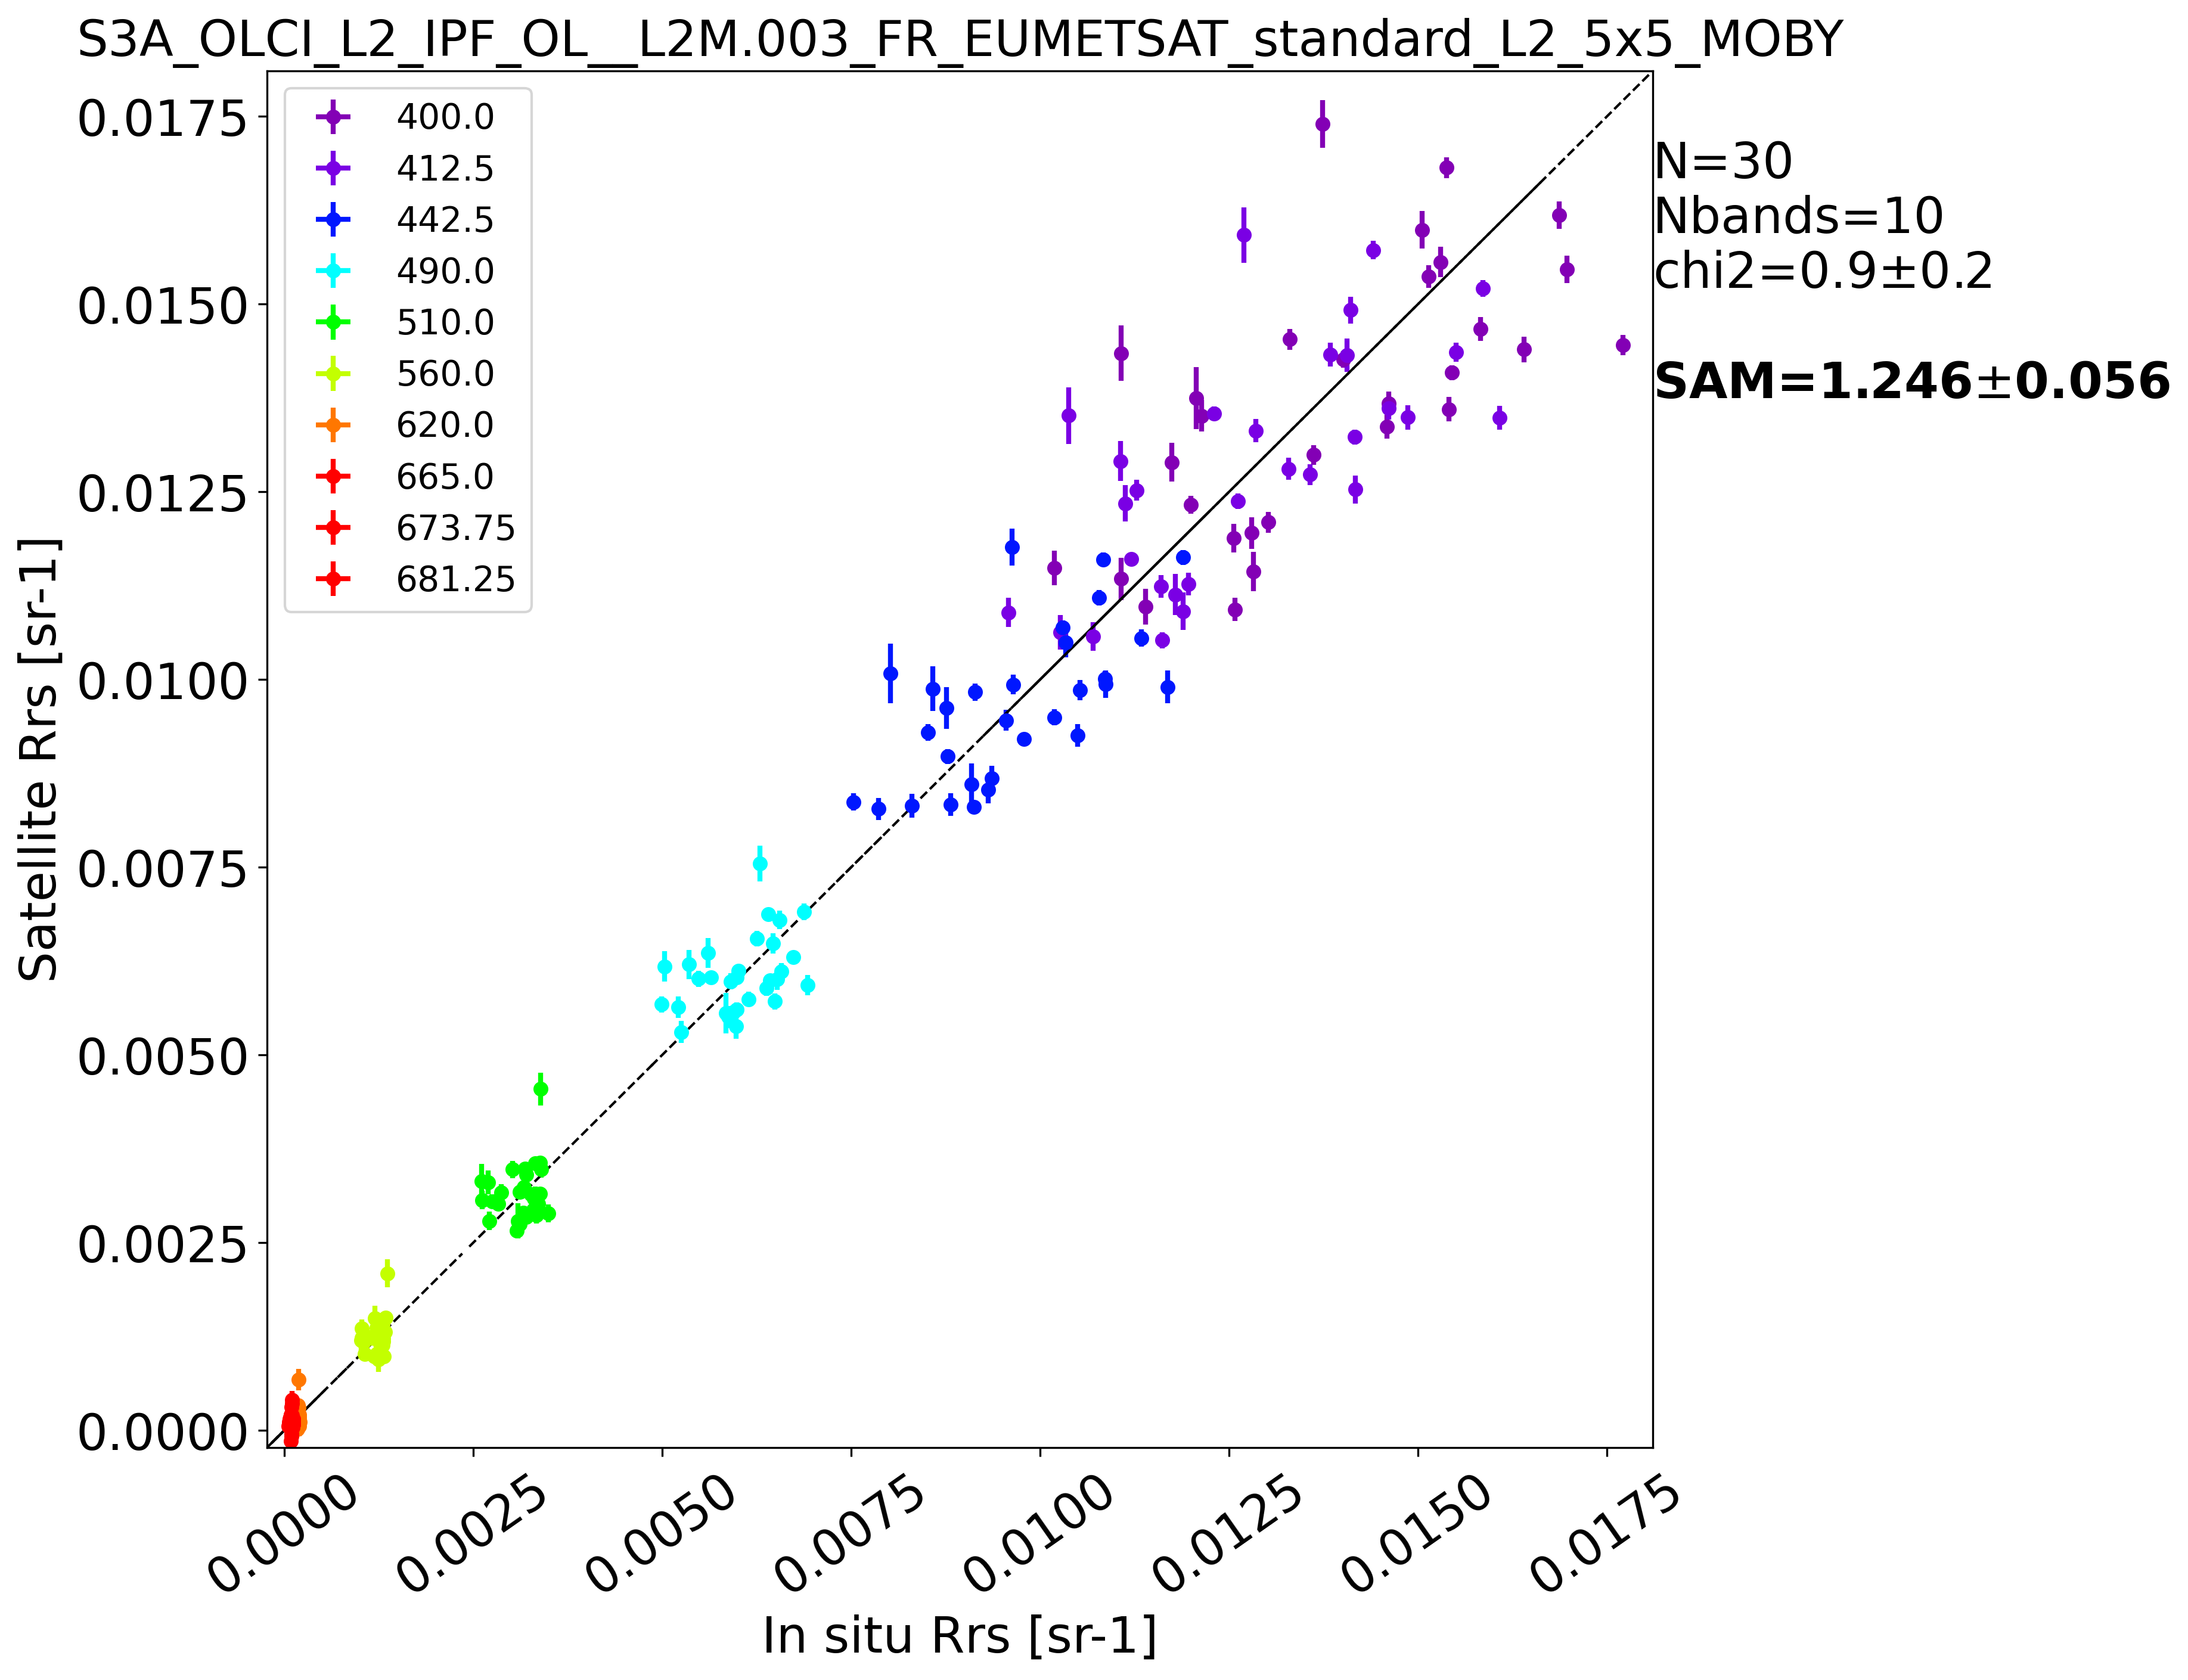

In [17]:
images = glob.glob(os.path.join(output_path, "MDB", "*Scatter*.png"))
for image in sorted(images):
    display(Image(image))

<div class="alert alert-info" role="alert">

## <a id='section5'></a>Example 3: Full match-up exercise with *in situ* data from an AERONET-OC site (<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-science-studies/ThoMaS/-/blob/main/README_examples.md?ref_type=heads" target="_blank">ThoMaS example 9</a>)
[Back to top](#TOC-TOP)

</div>

<div class="alert alert-success" role="alert">

Run ThoMaS for:

1. full matchup exercise: satellite extractions + minifiles + extraction statistics + matchup statistics
1. download insitu data from AERONET-OC station Casablanca_Platform and convert to SeaBASS/OCDB format
1. apply <a href="https://ioccg.org/bibliography/morel-a-antoine-d-and-b-gentili-2002/" target="_blank">Morel, Antoine and Gentili, 2002</a>
1. EUMETSAT standard protocol for extractions and for insitu-extraction comparison.

</div>

#### Description

<hr>

In this final example we are going to perform a full analysis using a subset of data from the MOBY ocean colour database as our *in situ* data.

1. Run ThoMaS using a subset of <a href="https://seabass.gsfc.nasa.gov/wiki/AERONET-OC" target="_blank">AERONET-OC<a/> data belonging to the Casablanca_Platform (PI Marco Talone and Frederic Melin)
1. I am interested only in using AERONET-OC data of quality level 1.5.
1. I wish to get matchups between this AERONET-OC subset and S3A/OLCI standard FR Level 2 SatData:
    * using the standard extraction protocol from EUMETSAT,
    * an extraction window of 3x3,
    * an insitu-satellite time difference threshold of 1 hour (3600 seconds).
    * to propagate - if existent - "uncertainties" in insitu and/or satellite data to the performance metrics by running Monte-Carlo simulations. NB: For the moment, the "uncertainty" in the satellite data is usually taken as the standard deviation of the set of valid macropixels.
1. I am not interested in getting ancillary data from ECMWF corresponding to the insitu data.
1. I want to apply the Morel, Antoine and Gentili 2002 BRDF correction to both satellite and insitu.
1. I may have several insitu measurements corresponding to one single SatData within the time window that I selected, but I wish to keep only the closest in time with the satellite overpass.
1. I wish my satellite data to be stored in the ./MOBY/SatData directory. All the other outputs (IDB, minifiles, EDB, MDB, etc.) to be stored in the ./MOBY directory
the other outputs (IDB, minifiles, EDB, MDB, etc.) to be stored in the "MOBY" directory.

<hr>

We are going to perform similar steps to those in example 1, beginning with defining our output path.

In [18]:
# Define and create your main output path for this example:
output_path = os.path.join(os.getcwd(), "Casablanca_Platform")
if not os.path.exists(output_path):
    os.mkdir(output_path)

And, as in example 2, we will build our configuration file. This time, however, we need to make some adaptations to ensure that we use the remote AERONET-OC data as our *in situ* validation source.

In [19]:
# Build your config_file.ini
path_to_config_file = os.path.join(output_path, 'config_file.ini')
config_params = {}

# global
config_params['global'] = {}
config_params['global']['path_output'] = output_path
config_params['global']['SetID'] = 'Casablanca_Platform'

# workflow
config_params['workflow'] = {}
config_params['workflow']['workflow'] = 'insitu, SatData, minifiles, EDB, MDB'

# AERONETOC
config_params['AERONETOC'] = {}
config_params['AERONETOC']['AERONETOC_pathNative'] = os.path.join(output_path, 'AERONETOC_native')
config_params['AERONETOC']['AERONETOC_dateStart'] = '2024-03-01T00:00:00'
config_params['AERONETOC']['AERONETOC_dateEnd'] = '2024-08-01T00:00:00'
config_params['AERONETOC']['AERONETOC_dataLevel'] = 1.5
config_params['AERONETOC']['AERONETOC_station'] = 'Casablanca_Platform'

# insitu
config_params['insitu'] = {}
config_params['insitu']['insitu_data2OCDBfile'] = "AERONETOC"
config_params['insitu']['insitu_input'] = os.path.join(output_path, 'Casablanca_Platform.sb')
config_params['insitu']['insitu_satelliteTimeToleranceSeconds'] = 3600
config_params['insitu']['insitu_getAncillary'] = False 
config_params['insitu']['insitu_BRDF'] = 'M02'

# satellite
config_params['satellite'] = {}
config_params['satellite']['satellite_path-to-SatData'] = os.path.join(output_path, 'SatData')
config_params['satellite']['satellite_source'] = 'online'
config_params['satellite']['satellite_platforms'] = 'PACE, NOAA-20'
config_params['satellite']['satellite_resolutions'] = 'FR'
config_params['satellite']['satellite_BRDF'] = 'M02'

# minifiles
config_params['minifiles'] = {}
config_params['minifiles']['minifiles_winSize'] = 5

# EDB
config_params['EDB'] = {}
config_params['EDB']['EDB_protocols_L2'] = 'EUMETSAT_standard_L2, Bailey_and_Werdell_2006'
config_params['EDB']['EDB_winSizes'] = "3, 5"

# MDB
config_params['MDB'] = {}
config_params['MDB']['MDB_time-interpolation'] = 'insitu2satellite_NN'
config_params['MDB']['MDB_stats_plots'] = True
config_params['MDB']['MDB_stats_protocol'] = 'EUMETSAT_standard_L2'

# Write config_params sections into config_file.ini
write_config_file(path_to_config_file, config_params)

...and run!

In [20]:
# Run ThoMaS and check all the outputs in the output directory
ThoMaS(path_to_config_file)


Running Casablanca_Platform

Building satellite_datasets file from specified options in config_file...

Step insitu
Creating IDB (in situ database) netcdf file and calculating timeRanges and satellite datasets from input SeaBASS/OCDB file (in situ)
Sanitised file successfully saved: /Users/benloveday/Code/git_repositories/CMTS/internal/ocean/sensors/learn-olci/2_OLCI_advanced/Casablanca_Platform/Casablanca_Platform_sanitised.sb
Header "water_depth" could not be converted to body field, check header value.
Computing spectral reconstruction method from Talone, Zibordi and Pitarch
In situ uncertainties propagated through spectral match scheme via simple Monte Carlo approach

Step SatData
satellite_download_option changed to "list_only", because satellite_source: "local"
No SatData found locally for SetID "Casablanca_Platform", Platform "PACE", Sensor "OCI", Level "L2", Processor "l2gen", Collection "OBPG", Resolution "FR", path_to_latLonTimeRanges "/Users/benloveday/Code/git_repositories

...and check our outputs.

In [21]:
images = glob.glob(os.path.join(output_path, "MDB", "*Scatter*.png"))
for image in sorted(images):
    display(Image(image))

<div class="alert alert-info" role="alert">

## <a id='section6'></a>What next?
[Back to top](#TOC-TOP)

</div>

You can find many more example of configuration files in the ./ThoMaS/examples directory. Building on these, and the examples shown above you should be able to build a validation workflow that works for your circumstances!

<hr>
<a href="../Index.ipynb" target="_blank"><< Index</a>
<br>
<a href="./2_4_OLCI_matchup_validation.ipynb" target="_blank"><< OLCI validation with the ThoMaS match-up toolkit</a>
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/ocean" target="_blank">View on GitLab</a> | <a href="https://training.eumetsat.int/" target="_blank">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int target="_blank">Contact helpdesk for support </a> | <a href=mailto:training@eumetsat.int target="_blank">Contact our training team to collaborate on and reuse this material</a></span></p>